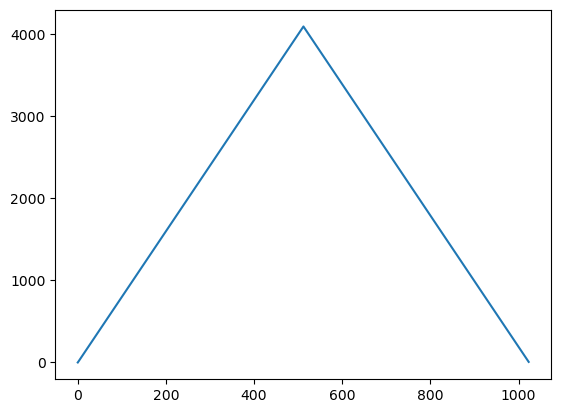

uint16_t sine_LUT[4096] = {
2047, 2050, 2053, 2056, 2060, 2063, 2066, 2069, 2072, 2075, 2078, 2082, 2085, 2088, 2091, 2094, 
2097, 2100, 2104, 2107, 2110, 2113, 2116, 2119, 2122, 2126, 2129, 2132, 2135, 2138, 2141, 2144, 
2147, 2151, 2154, 2157, 2160, 2163, 2166, 2169, 2173, 2176, 2179, 2182, 2185, 2188, 2191, 2194, 
2198, 2201, 2204, 2207, 2210, 2213, 2216, 2220, 2223, 2226, 2229, 2232, 2235, 2238, 2241, 2245, 
2248, 2251, 2254, 2257, 2260, 2263, 2266, 2270, 2273, 2276, 2279, 2282, 2285, 2288, 2291, 2295, 
2298, 2301, 2304, 2307, 2310, 2313, 2316, 2319, 2323, 2326, 2329, 2332, 2335, 2338, 2341, 2344, 
2347, 2351, 2354, 2357, 2360, 2363, 2366, 2369, 2372, 2375, 2378, 2382, 2385, 2388, 2391, 2394, 
2397, 2400, 2403, 2406, 2409, 2413, 2416, 2419, 2422, 2425, 2428, 2431, 2434, 2437, 2440, 2443, 
2446, 2450, 2453, 2456, 2459, 2462, 2465, 2468, 2471, 2474, 2477, 2480, 2483, 2486, 2489, 2493, 
2496, 2499, 2502, 2505, 2508, 2511, 2514, 2517, 2520, 2523, 2526, 2529, 2532, 2535, 2538, 2541, 
25

In [29]:
import numpy as np
import matplotlib.pyplot as plt

N = 4096  # number of samples
x = np.linspace(0, 2*np.pi, N, endpoint=False)

# Sine wave
sine = ((np.sin(x) + 1) / 2) * 4095

# Triangle wave using arcsin trick
up = np.linspace(0, 4095, 512, endpoint=False)
# Ramp down 4095 → 0
down = np.linspace(4095, 0, 512, endpoint=False)
triangle = triangle = np.concatenate((up, down)).astype(int)

# Sawtooth wave
sawtooth = (x / (2*np.pi)) * 4095

# Convert to integers
sine = sine.astype(int)
triangle = triangle.astype(int)
sawtooth = sawtooth.astype(int)

# Plot one of them
plt.plot(triangle)
plt.show()

def to_c_array(name, data):
    print(f"uint16_t {name}[{len(data)}] = {{")
    for i, val in enumerate(data):
        end = ", " if i < len(data)-1 else ""
        print(f"{val}{end}", end="")
        if (i+1) % 16 == 0:  # break line every 16 numbers
            print()
    print("};\n")

to_c_array("sine_LUT", sine)
to_c_array("triangle_LUT", triangle)
to_c_array("sawtooth_LUT", sawtooth)



Sample rate: 44100
Data shape: (499968, 2)


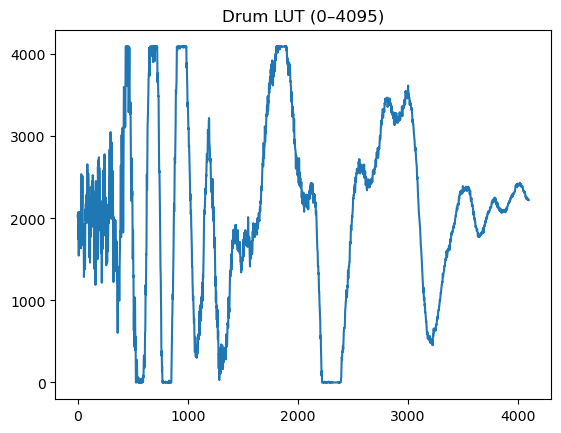

uint16_t Drum_LUT[4096] = {
2025, 2052, 2039, 1844, 1744, 1930, 2077, 1951, 1694, 1546, 1677, 1909, 1918, 1825, 1881, 1939, 
1840, 1751, 1855, 2049, 2076, 1911, 1777, 1770, 1875, 2054, 2082, 1851, 1635, 1671, 1982, 2419, 
2537, 2196, 1967, 2085, 2133, 2066, 2118, 2167, 2189, 2355, 2519, 2459, 2219, 1913, 1694, 1677, 
1763, 1845, 1903, 1890, 1873, 1911, 1800, 1484, 1286, 1345, 1496, 1677, 1865, 1931, 1826, 1637, 
1486, 1399, 1383, 1598, 1983, 2110, 1977, 2003, 2156, 2178, 2135, 2096, 2020, 1957, 1997, 2177, 
2291, 2121, 1944, 2026, 2168, 2309, 2542, 2659, 2532, 2383, 2380, 2383, 2218, 2114, 2329, 2549, 
2491, 2367, 2339, 2367, 2310, 1980, 1574, 1528, 1866, 2239, 2257, 2003, 1975, 2024, 1702, 1461, 
1715, 2034, 2159, 2149, 1977, 1822, 1789, 1778, 1889, 2071, 2060, 2009, 2189, 2391, 2348, 2179, 
2119, 2221, 2395, 2453, 2247, 2024, 2134, 2413, 2528, 2478, 2394, 2380, 2363, 2133, 1892, 1987, 
2165, 2157, 2199, 2325, 2249, 1913, 1517, 1384, 1624, 1848, 1823, 1856, 2029, 2048, 1858, 1599, 
13

In [33]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

# Load file
rate, data = wavfile.read("drum.wav")   # replace with your file
print("Sample rate:", rate)
print("Data shape:", data.shape)

# If stereo, take just one channel
if data.ndim > 1:
    data = data[:,0]

# --- Find start of activity ---
# Define a threshold for "activity" (adjust based on your audio)
threshold = 0.01 * np.max(np.abs(data))

# Find the first index where signal exceeds threshold
start_index = np.argmax(np.abs(data) > threshold)

# Use next N samples after the activity starts
N = 4096
snippet = data[start_index:start_index+N]

# --- Normalization ---
snippet = snippet / np.max(np.abs(snippet))

# Scale to 0 … 4095 (12-bit DAC)
snippet = ((snippet + 1) / 2) * 4095

# Convert to integers
snippet = snippet.astype(int)

plt.plot(snippet)
plt.title("Drum LUT (0–4095)")
plt.show()

def to_c_array(name, data):
    print(f"uint16_t {name}[{len(data)}] = {{")
    for i, val in enumerate(data):
        end = ", " if i < len(data)-1 else ""
        print(f"{val}{end}", end="")
        if (i+1) % 16 == 0:
            print()
    print("};\n")

to_c_array("Drum_LUT", snippet)
